# COMP20008 Assignment 2 - Code

**Research question:** Is the pricing of a property linked to its overall rating, and what kinds
of variation in pricing exists between properties?

Group W[XX]G[XX] - Sabir, Len, Ten, Ben

| Notebook section | Report section | Owner |
|---|---|---|
| 1. Setup | - | - |
| 2. Preprocessing | 2.1 / 3.1 / 4.1 / 5.1 | Sabir |
| 3. Correlation analysis | 2.2 / 3.2 / 4.2 / 5.2 | Len |
| 4. Supervised learning | 2.3 / 3.3 / 4.3 / 5.3 | Ten |
| 5. Feature selection | 2.4 / 3.4 / 4.4 / 5.4 | Ben |
| 6. PCA and clustering | 2.5 / 3.5 / 4.5 / 5.5 | Ben |

**To run:** place `listingsA2.csv` in a `data/` folder beside this notebook, then Run All.
Every section depends on the dataframes built in section 2, so run the cells in order.
Figures are written to `figures/` as well as displayed inline.

**Data:** Inside Airbnb. (2026). *Melbourne, Victoria, Australia.* http://insideairbnb.com/get-the-data/

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle

from scipy.stats import pearsonr, spearmanr, entropy
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list, dendrogram

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, mutual_info_score, adjusted_rand_score)
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     cross_validate, StratifiedKFold)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

pd.set_option('display.width', 200, 'display.max_columns', 20)
RANDOM_STATE = 42
os.makedirs('figures', exist_ok=True)

## 2. Preprocessing (section 2.1 - Sabir)

Three preprocessing tasks: a missing-data strategy for `review_scores_rating`, distance from the
CBD, and property-type consolidation. Produces `df` (all listings) and `df_rating` (the rated
subset), which every later section builds on.

In [2]:
df = pd.read_csv('data/listingsA2.csv', low_memory=False)   # Raw Inside Airbnb file (Amendment #1)

# Baseline: price -> numeric (needed before any price analysis)
def parse_price_correct(price):
    if pd.isna(price):
        return np.nan
    cleaned_price = str(price).replace('$', '').replace(',', '')
    try:
        return float(cleaned_price)
    except ValueError:
        return np.nan

df['price'] = df['price'].apply(parse_price_correct)

In [3]:
# ---- STEP 1: missing review_scores_rating ----
n_null = df['review_scores_rating'].isna().sum()
print(f"null ratings: {n_null} ({n_null/len(df)*100:.1f}%)")
# Confirm MNAR: every null rating is a 0-review listing
print("all nulls are 0-review:",
      (df.loc[df['review_scores_rating'].isna(), 'number_of_reviews'] == 0).all())

# Flag keeps 0-review rows usable for the price-VARIATION half of the RQ
df['is_reviewed'] = df['review_scores_rating'].notna()
# But rating-based analysis uses only genuine ratings (drop, not impute)
df_rating = df[df['is_reviewed']].copy()
print("rows:", len(df), "-> rating subset:", len(df_rating))

# Impact: drop vs impute on downstream correlation
paired = df.dropna(subset=['price']) # Only keep rows with a price
drop_sp = df_rating['price'].corr(df_rating['review_scores_rating'], method='spearman') # Price vs rating on valid rows only
imp = df['review_scores_rating'].fillna(df['review_scores_rating'].median()) # Impute with median method
impute_sp = paired['price'].corr(imp.loc[paired.index], method='spearman') # Price vs rating (nulls imputed with median)
print(f"Spearman price~rating | drop {drop_sp:.4f} | impute {impute_sp:.4f}") # Print results for both methods of dealing with NaN values

null ratings: 4477 (17.4%)
all nulls are 0-review: True
rows: 25728 -> rating subset: 21251
Spearman price~rating | drop 0.0921 | impute 0.0796


In [4]:
# ---- STEP 2: distance from Melbourne CBD ----
CBD_LAT, CBD_LON = -37.8136, 144.9631 # Flinders St, Melbourne CBD

def haversine_km(lat, lon, clat=CBD_LAT, clon=CBD_LON):
    """Distance (km) from each listing to the CBD via haversine (accounts for Earth's curvature)."""
    R = 6371.0 # Earth radius, km
    dlat = np.radians(clat - lat)
    dlon = np.radians(clon - lon)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat))*np.cos(np.radians(clat))*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a)) # Great-circle distance to CBD

# Continuous feature
df['distance_from_cbd_km'] = haversine_km(df['latitude'], df['longitude'])

# Discretised bands (for description / plots)
df['cbd_band'] = pd.cut(df['distance_from_cbd_km'], bins=[-0.1, 5, 15, np.inf],
                        labels=['inner', 'middle', 'outer'])

# Impact: band sizes + price by band + price~distance correlation
print("distance km min/median/max:",
      round(df['distance_from_cbd_km'].min(),2),
      round(df['distance_from_cbd_km'].median(),2),
      round(df['distance_from_cbd_km'].max(),2))
dist_sp = df['price'].corr(df['distance_from_cbd_km'], method='spearman') # Spearman correlation between price and continuous distance
print(f"Spearman price~distance: {dist_sp:.4f}")

# Make and print a summary of the distance-from-CBD preprocessing step
cbd_band_df = pd.DataFrame()
cbd_band_df['number_of_listings'] = df.groupby('cbd_band', observed=True).size()
cbd_band_df['median_price'] = df.groupby('cbd_band', observed=True)['price'].median()
cbd_band_df.index.name = None
print(cbd_band_df)

distance km min/median/max: 0.02 5.11 80.0
Spearman price~distance: -0.0484
        number_of_listings  median_price
inner                12722         253.0
middle                6953         219.5
outer                 6053         247.5


In [5]:
# ---- STEP 3: property-type consolidation ----
# 82 raw categories (41 with <10 listings) -> 5 dwelling-type groups
# Room_type already captures entire/private/shared, so we group by DWELLING type
def group_property_type(raw_type):
    """Map raw property_type to a dwelling-type group."""
    type_lower = str(raw_type).lower()
    if any(keyword in type_lower for keyword in
           ['hotel', 'hostel', 'guesthouse', 'guest suite', 'bed and breakfast', 'resort']):
        return 'Hotel/B&B'
    if 'townhouse' in type_lower:
        return 'Townhouse'
    if any(keyword in type_lower for keyword in
           ['rental unit', 'condo', 'serviced apartment', 'loft', 'apartment']):
        return 'Apartment/unit'
    if any(keyword in type_lower for keyword in
           ['home', 'house', 'cottage', 'cabin', 'villa', 'bungalow', 'tiny', 'farm', 'vacation', 'chalet', 'earthen']):
        return 'House'
    return 'Other'

df['property_group'] = df['property_type'].apply(group_property_type)

# Impact: category collapse + rare-category share + price by group
raw_counts = df['property_type'].value_counts()
n_rare = (raw_counts < 10).sum()
rare_share = raw_counts[raw_counts < 10].sum() / len(df) * 100
print(f"BEFORE {len(raw_counts)} categories | {n_rare} have <10 listings ({rare_share:.2f}% of rows)")
print(f"AFTER {df['property_group'].nunique()} groups")

# Make and print a summary of the property-type consolidation preprocessing step
property_type_df = pd.DataFrame()
property_type_df['number_of_listings'] = df.groupby('property_group').size()
property_type_df['median_price'] = df.groupby('property_group')['price'].median()
property_type_df.index.name = None
print(property_type_df)

BEFORE 82 categories | 41 have <10 listings (0.43% of rows)
AFTER 5 groups
                number_of_listings  median_price
Apartment/unit               14477         248.0
Hotel/B&B                     1335         185.0
House                         8896         248.0
Other                          124         236.0
Townhouse                      896         292.5


In [6]:
# ---- Refresh rated subset ----
# df_rating was created in Step 1, before Steps 2-3 added 'distance_from_cbd_km',
# 'cbd_band' and 'property_group'. Rebuild it so the rated subset has every engineered column.
df_rating = df[df['is_reviewed']].copy()
print("rating subset rows:", len(df_rating), "| has new columns:",
      {'distance_from_cbd_km', 'cbd_band', 'property_group'}.issubset(df_rating.columns))

rating subset rows:

 21251 | has new columns: True


## 3. Correlation analysis (section 2.2 - Len)

Pearson, Spearman, MI and NMI for every pair in the chosen variable set, with pairwise deletion
so each pair uses every row where both variables are present.

In [7]:
print("\n" + "="*60)
print("2.2 CORRELATION ANALYSIS")
print("="*60)

# ---- Variable set + measurement level (decides which methods apply) ----
VARS = {
    'price':                'continuous',  # target, kept continuous
    'review_scores_rating': 'continuous',
    'distance_from_cbd_km': 'continuous',
    'accommodates':         'discrete',    # integer count, equal intervals
    'bedrooms':             'discrete',
    'room_type':            'nominal',     # categorical, no order
    'property_group':       'nominal',
}
N_BINS = 5   # equal-frequency bins for numeric variables in MI/NMI

# Rated + priced listings (rating nulls already dropped in 2.1)
base = df_rating.dropna(subset=['price'])
print(f"rated + priced listings: {len(base)}")

# Pairwise deletion: each pair uses every row where BOTH of its variables are present.
# Only bedrooms has gaps, so pairs without bedrooms keep all rated + priced listings.
corr_df = base[list(VARS)].copy()
print("missing values per variable:", corr_df.isna().sum()[lambda s: s > 0].to_dict())
print("price min/median/max:", corr_df['price'].min(), corr_df['price'].median(), corr_df['price'].max())

# Numeric view for Pearson/Spearman: log(price) tames the right skew for Pearson;
# Spearman is rank-based, so the log does not change its value
num = corr_df.copy()
num['price'] = np.log(num['price'])

# Discrete view for MI/NMI: numeric vars -> equal-frequency bins (skew-robust),
# binned once per variable on all its non-missing values so edges are the same in every pair.
# Ties (e.g. many 5.0 ratings) can merge edges, so report the bins actually produced
disc = pd.DataFrame(index=corr_df.index)
for v, kind in VARS.items():
    if kind in ('continuous', 'discrete'):
        binned, edges = pd.qcut(corr_df[v], q=N_BINS, duplicates='drop', retbins=True)
        disc[v] = binned.cat.codes.where(corr_df[v].notna())   # keep NaN (not code -1)
        if v == 'price':
            print("price bin edges for MI ($):", [round(float(e), 2) for e in edges])
    else:
        disc[v] = corr_df[v].astype(str)
print("categories used for MI/NMI:", {v: disc[v].nunique() for v in VARS})


2.2 CORRELATION ANALYSIS
rated + priced listings: 16375
missing values per variable: {'bedrooms': 2317}
price min/median/max: 7.48 247.84 50093.56
price bin edges for MI ($): [7.48, 145.33, 216.0, 280.5, 380.0, 50093.56]
categories used for MI/NMI: {'price': 5, 'review_scores_rating': 4, 'distance_from_cbd_km': 5, 'accommodates': 5, 'bedrooms': 4, 'room_type': 4, 'property_group': 5}


In [8]:
# ---- Pairwise measures ----
def mi_bits(x, y):
    return mutual_info_score(x, y) / np.log(2)   # sklearn uses nats -> convert to bits

def h_bits(x):
    return entropy(pd.Series(x).value_counts(), base=2)

def na_reason(v1, v2):
    """Pearson/Spearman need ordered values; return why not, or None if they apply."""
    for v in (v1, v2):
        if VARS[v] == 'nominal':
            return f"N/A: {v} is nominal (no order)"
    return None

def pair_stats(v1, v2, keep):
    """All four measures for one pair, computed on the rows in `keep`."""
    row = {'var1': v1, 'var2': v2, 'n': int(keep.sum())}
    reason = na_reason(v1, v2)
    if reason is None:
        row['pearson_r'], row['pearson_p'] = pearsonr(num.loc[keep, v1], num.loc[keep, v2])
        row['spearman_rho'], row['spearman_p'] = spearmanr(num.loc[keep, v1], num.loc[keep, v2])
        row['note'] = 'Pearson uses log(price)' if 'price' in (v1, v2) else ''
    else:
        row['pearson_r'] = row['pearson_p'] = row['spearman_rho'] = row['spearman_p'] = np.nan
        row['note'] = 'Pearson & Spearman ' + reason

    # MI/NMI apply to every pair (nominal included); NMI = MI / mean(H(X), H(Y))
    # (arithmetic mean, same as sklearn's default; min would inflate low-entropy room_type)
    x, y = disc.loc[keep, v1], disc.loc[keep, v2]
    mi = mi_bits(x, y)
    row['MI_bits'] = mi
    row['NMI'] = mi / ((h_bits(x) + h_bits(y)) / 2)
    return row

COLS = ['var1', 'var2', 'n', 'pearson_r', 'pearson_p', 'spearman_rho', 'spearman_p', 'MI_bits', 'NMI', 'note']

# Main table: pairwise deletion (rows where both variables are present)
results = pd.DataFrame([pair_stats(v1, v2, corr_df[[v1, v2]].notna().all(axis=1))
                        for v1, v2 in combinations(VARS, 2)])[COLS]

pd.set_option('display.width', 200, 'display.max_columns', 20, 'display.max_colwidth', 80)
print(f"\nAll {len(results)} pairs (pairwise n, values used: {sorted(results['n'].unique())}):")
print(results.round(4).to_string(index=False))

# Target pairs, ranked by NMI (the one measure available for every variable)
target = results[(results['var1'] == 'price') | (results['var2'] == 'price')]
print("\nPairs with price, sorted by NMI:")
print(target.sort_values('NMI', ascending=False)
            [['var1', 'var2', 'n', 'pearson_r', 'spearman_rho', 'MI_bits', 'NMI']].round(4).to_string(index=False))

# Like-for-like check: price pairs recomputed on the rows that have bedrooms, so bedrooms
# pairs (n smaller) can be compared with the other predictors on the same listings
common = corr_df.notna().all(axis=1)
same_n = pd.DataFrame([pair_stats('price', v, common) for v in VARS if v != 'price'])[COLS]
print(f"\nPairs with price on the common sample (n = {int(common.sum())}, rows with bedrooms):")
print(same_n.sort_values('NMI', ascending=False)
            [['var1', 'var2', 'n', 'pearson_r', 'spearman_rho', 'MI_bits', 'NMI']].round(4).to_string(index=False))

# Square matrices per method (handy for heatmaps)
for col in ['pearson_r', 'spearman_rho', 'NMI']:
    m = results.pivot(index='var1', columns='var2', values=col)
    print(f"\n{col} matrix:")
    print(m.reindex(index=list(VARS)[:-1], columns=list(VARS)[1:]).round(4).to_string())


All 21 pairs (pairwise n, values used: [np.int64(14058), np.int64(16375)]):
                var1                 var2     n  pearson_r  pearson_p  spearman_rho  spearman_p  MI_bits    NMI                                                         note
               price review_scores_rating 16375     0.1117     0.0000        0.0921      0.0000   0.0156 0.0074                                      Pearson uses log(price)
               price distance_from_cbd_km 16375     0.0388     0.0000       -0.0308      0.0001   0.0497 0.0214                                      Pearson uses log(price)
               price         accommodates 16375     0.6116     0.0000        0.6946      0.0000   0.4108 0.1873                                      Pearson uses log(price)
               price             bedrooms 14058     0.5543     0.0000        0.6363      0.0000   0.3542 0.1746                                      Pearson uses log(price)
               price            room_type 16375        NaN


saved figures/correlation_heatmaps.png


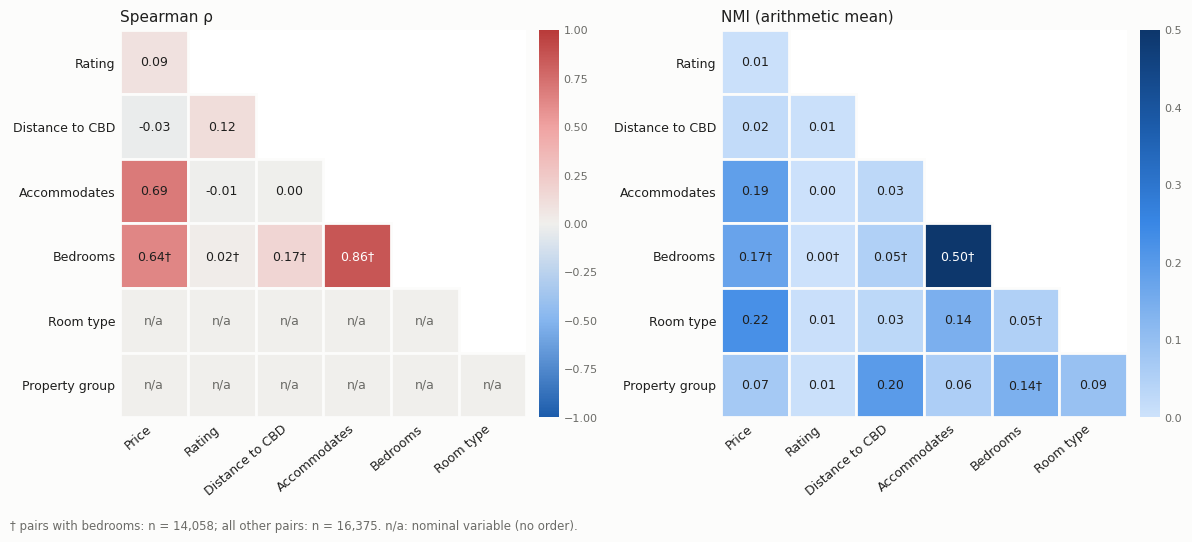

In [9]:
# ---- Figure: Spearman + NMI heatmaps (lower triangle, values in cells) ----

LABELS = {'price': 'Price', 'review_scores_rating': 'Rating', 'distance_from_cbd_km': 'Distance to CBD',
          'accommodates': 'Accommodates', 'bedrooms': 'Bedrooms', 'room_type': 'Room type',
          'property_group': 'Property group'}
INK, MUTED, SURFACE, NA_FILL = '#1f1f1e', '#6b6b67', '#fcfcfb', '#f0efec'
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b'])
DIV = LinearSegmentedColormap.from_list('div_blue_red', ['#1c5cab', '#86b6ef', NA_FILL, '#f0a3a2', '#b83a39'])

def full_matrix(col):
    """Symmetric matrix of one measure from the pairwise results table."""
    m = pd.DataFrame(np.nan, index=list(VARS), columns=list(VARS))
    for _, r in results.iterrows():
        m.loc[r['var1'], r['var2']] = m.loc[r['var2'], r['var1']] = r[col]
    return m

def text_colour(rgb):
    """Dark ink on light cells, white on dark cells (relative luminance)."""
    lum = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    return INK if lum > 0.45 else 'white'

def heatmap(ax, col, cmap, norm, title):
    m, names = full_matrix(col), list(VARS)
    rows, cols = names[1:], names[:-1]
    for i, rv in enumerate(rows):
        for j, cv in enumerate(cols[:i + 1]):
            val = m.loc[rv, cv]
            fill = NA_FILL if np.isnan(val) else cmap(norm(val))
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor=fill, edgecolor=SURFACE, lw=2))
            if np.isnan(val):   # method not applicable (nominal variable)
                ax.text(j + .5, i + .5, 'n/a', ha='center', va='center', fontsize=9, color=MUTED)
            else:
                mark = '†' if 'bedrooms' in (rv, cv) else ''
                label = f'{val:.2f}'.replace('-0.00', '0.00')   # no negative zero
                ax.text(j + .5, i + .5, label + mark, ha='center', va='center', fontsize=9,
                        color=text_colour(to_rgb(fill)))
    ax.set_xlim(0, len(cols)); ax.set_ylim(len(rows), 0)
    ax.set_xticks(np.arange(len(cols)) + .5, [LABELS[c] for c in cols], rotation=40, ha='right')
    ax.set_yticks(np.arange(len(rows)) + .5, [LABELS[r] for r in rows])
    ax.tick_params(length=0, colors=INK, labelsize=9)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(title, loc='left', fontsize=11, color=INK)
    cb = ax.figure.colorbar(ScalarMappable(norm, cmap), ax=ax, fraction=0.046, pad=0.03)
    cb.outline.set_visible(False); cb.ax.tick_params(labelsize=8, colors=MUTED, length=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.4), facecolor=SURFACE)
heatmap(ax1, 'spearman_rho', DIV, Normalize(-1, 1), 'Spearman ρ')
heatmap(ax2, 'NMI', SEQ, Normalize(0, 0.5), 'NMI (arithmetic mean)')
fig.text(0.01, 0.01, f"† pairs with bedrooms: n = {results['n'].min():,}; all other pairs: n = {results['n'].max():,}. "
         "n/a: nominal variable (no order).", fontsize=8.5, color=MUTED)
fig.tight_layout(rect=(0, 0.04, 1, 1))
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/correlation_heatmaps.png', dpi=200, facecolor=SURFACE)
print("\nsaved figures/correlation_heatmaps.png")

## 4. Supervised learning (section 2.3 - Ten)

Price is discretised into three equal-count bands and predicted with KNN and a Decision Tree.
Hyperparameters are chosen by 5-fold stratified CV on the training set only; the test set is
touched once, for the final reported metrics.

In [10]:
RANDOM_STATE = 42

# Target Construction

print("\n" + "="*60)
print("2.3 SUPERVISED LEARNING - target variable construction")
print("="*60)

# Rated subset only: review_scores_rating is a core feature for the RQ, and its
# missingness is MNAR (every null = 0-review listing), so imputing would invent ratings.
base = df_rating.dropna(subset=['price']).copy()

print(f"all listings: {len(df)}")
print(f"rated subset: {len(df_rating)}")
print(f"rated + priced: {len(base)}  (dropped {len(df_rating) - len(base)} rows with NaN price)")

print("\nprice extremes:")
print(f"  min {base['price'].min():.2f} | median {base['price'].median():.2f} | max {base['price'].max():.2f}")
print(f"  price == 0: {(base['price'] == 0).sum()} rows")
print(f"  price > 1000: {(base['price'] > 1000).sum()} rows")

base['price_band'], bins = pd.qcut(base['price'], q=3,
                                   labels=['low', 'mid', 'high'], retbins=True)

print("\ncut points ($):", [round(b, 2) for b in bins])
print(f"  low:  {bins[0]:.2f} - {bins[1]:.2f}")
print(f"  mid:  {bins[1]:.2f} - {bins[2]:.2f}")
print(f"  high: {bins[2]:.2f} - {bins[3]:.2f}")

counts = base['price_band'].value_counts().sort_index()
print("\nclass balance:")
for band, n in counts.items():
    print(f"  {band:5s} {n:6d}  ({n/len(base)*100:.1f}%)")

majority_baseline = counts.max() / len(base)
print(f"\nmajority-class (0R) baseline accuracy: {majority_baseline:.4f}")


2.3 SUPERVISED LEARNING - target variable construction
all listings: 25728
rated subset: 21251
rated + priced: 16375  (dropped 4876 rows with NaN price)

price extremes:
  min 7.48 | median 247.84 | max 50093.56
  price == 0: 0 rows
  price > 1000: 271 rows

cut points ($): [np.float64(7.48), np.float64(194.25), np.float64(307.0), np.float64(50093.56)]
  low:  7.48 - 194.25
  mid:  194.25 - 307.00
  high: 307.00 - 50093.56

class balance:
  low     5460  (33.3%)
  mid     5465  (33.4%)
  high    5450  (33.3%)

majority-class (0R) baseline accuracy: 0.3337


In [11]:
print("\n" + "="*60)


# Encoding the Column

print("FEATURE MATRIX - encoding")
print("="*60)

# bedrooms is the only chosen feature with meaningful missingness, so check whether
# the nulls track room_type before picking a fill strategy.
print("\nbedrooms nulls by room_type:")
for rt, grp in base.groupby('room_type'):
    n_null = grp['bedrooms'].isna().sum()
    print(f"  {rt:16s} {n_null:5d} / {len(grp):5d}  ({n_null/len(grp)*100:5.1f}%)")

base['bedrooms'] = base.groupby('room_type')['bedrooms'].transform(lambda s: s.fillna(s.median()))
base['bedrooms'] = base['bedrooms'].fillna(base['bedrooms'].median())
print(f"\nbedrooms nulls after within-room_type median impute: {base['bedrooms'].isna().sum()}")

NUMERIC = ['review_scores_rating', 'accommodates', 'bedrooms', 'distance_from_cbd_km']
CATEGORICAL = ['room_type', 'property_group']

# drop_first=False keeps every level as its own column so the tree's feature
# importances stay readable for the feature-selection section.
X = pd.get_dummies(base[NUMERIC + CATEGORICAL], columns=CATEGORICAL, drop_first=False)
X = X.astype(float)
y = base['price_band']

print(f"\nnumeric features      : {len(NUMERIC)}  {NUMERIC}")
print(f"categorical features  : {len(CATEGORICAL)} -> one-hot expanded")
print(f"\nX shape: {X.shape}   y shape: {y.shape}")
print(f"total feature columns after encoding: {X.shape[1]}")
print("\ncolumns:")
for i, c in enumerate(X.columns, 1):
    print(f"  {i:2d}. {c}")
print(f"\nany nulls left in X: {X.isna().sum().sum()}")


FEATURE MATRIX - encoding

bedrooms nulls by room_type:
  Entire home/apt    347 / 12883  (  2.7%)
  Hotel room           4 /    40  ( 10.0%)
  Private room      1905 /  3337  ( 57.1%)
  Shared room         61 /   115  ( 53.0%)

bedrooms nulls after within-room_type median impute: 0

numeric features      : 4  ['review_scores_rating', 'accommodates', 'bedrooms', 'distance_from_cbd_km']
categorical features  : 2 -> one-hot expanded

X shape: (16375, 13)   y shape: (16375,)
total feature columns after encoding: 13

columns:
   1. review_scores_rating
   2. accommodates
   3. bedrooms
   4. distance_from_cbd_km
   5. room_type_Entire home/apt
   6. room_type_Hotel room
   7. room_type_Private room
   8. room_type_Shared room
   9. property_group_Apartment/unit
  10. property_group_Hotel/B&B
  11. property_group_House
  12. property_group_Other
  13. property_group_Townhouse

any nulls left in X: 0


In [12]:
print("\n" + "="*60)
print("TRAIN / TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"\ntrain: {len(X_train)} rows | test: {len(X_test)} rows  (80/20)")
print("\nstratification check (share per band):")
print(f"  {'band':6s} {'full':>8s} {'train':>8s} {'test':>8s}")
for band in ['low', 'mid', 'high']:
    print(f"  {band:6s} {(y == band).mean():8.4f} {(y_train == band).mean():8.4f} {(y_test == band).mean():8.4f}")

# KNN compares listings by distance, so features on wider ranges would dominate.
# Fitted on train only: fitting on all rows would leak test distribution into training.
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nscaled copies built for KNN (scaler fitted on train only)")


TRAIN / TEST SPLIT

train: 13100 rows | test: 3275 rows  (80/20)

stratification check (share per band):
  band       full    train     test
  low      0.3334   0.3334   0.3334
  mid      0.3337   0.3337   0.3337
  high     0.3328   0.3328   0.3328

scaled copies built for KNN (scaler fitted on train only)


In [13]:
print("\n" + "="*60)
print("BASELINE + DEFAULT MODELS")
print("="*60)

def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average='macro')
    print(f"  {name:34s} accuracy {acc:.4f} | macro-F1 {macro:.4f}")
    return acc, macro

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

knn_default = KNeighborsClassifier()
knn_default.fit(X_train_scaled, y_train)

tree_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_default.fit(X_train, y_train)

print("\ntest-set performance:")
base_acc, base_f1 = report("majority baseline (0R)", y_test, dummy.predict(X_test))
knn_acc, knn_f1 = report("KNN (default k=5)", y_test, knn_default.predict(X_test_scaled))
tree_acc, tree_f1 = report("Decision Tree (default, unpruned)", y_test, tree_default.predict(X_test))

print("\nimprovement over baseline (absolute, accuracy):")
print(f"  KNN           {knn_acc - base_acc:+.4f}")
print(f"  Decision Tree {tree_acc - base_acc:+.4f}")

print(f"\ntree depth when unconstrained: {tree_default.get_depth()} | leaves: {tree_default.get_n_leaves()}")
print(f"tree train accuracy: {accuracy_score(y_train, tree_default.predict(X_train)):.4f}"
      f"  (vs test {tree_acc:.4f}) -> overfitting gap")


BASELINE + DEFAULT MODELS



test-set performance:
  majority baseline (0R)             accuracy 0.3337 | macro-F1 0.1668


  KNN (default k=5)                  accuracy 0.6250 | macro-F1 0.6232
  Decision Tree (default, unpruned)  accuracy 0.5966 | macro-F1 0.5969

improvement over baseline (absolute, accuracy):
  KNN           +0.2913
  Decision Tree +0.2629

tree depth when unconstrained: 43 | leaves: 4533
tree train accuracy: 0.9988  (vs test 0.5966) -> overfitting gap


In [14]:
print("\n" + "="*60)
print("FEATURE SET CHOICE: keep or drop 'bedrooms'")
print("="*60)
print("\nSpearman accommodates~bedrooms = 0.8643 (2.2, n = 14,058), so the two")
print("carry largely the same information. Decided by 5-fold CV on the TRAINING")
print("set only, leaving the test set untouched for the final reported metric.")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Scaler lives inside the pipeline so it refits on each CV fold's training
# portion rather than seeing the whole training set.
knn_pipe = Pipeline([('scale', StandardScaler()), ('knn', KNeighborsClassifier())])

feature_sets = {
    'keep both': list(X_train.columns),
    'drop bedrooms': [c for c in X_train.columns if c != 'bedrooms'],
    'drop accommodates': [c for c in X_train.columns if c != 'accommodates'],
}

print(f"\n{'feature set':20s} {'cols':>5s} {'KNN macro-F1':>16s} {'Tree macro-F1':>16s}")
cv_results = {}
for label, cols in feature_sets.items():
    knn_cv = cross_val_score(knn_pipe, X_train[cols], y_train,
                             cv=cv, scoring='f1_macro')
    tree_cv = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE),
                              X_train[cols], y_train, cv=cv, scoring='f1_macro')
    cv_results[label] = (knn_cv, tree_cv)
    print(f"{label:20s} {len(cols):5d} {knn_cv.mean():10.4f} +/-{knn_cv.std():.4f} "
          f"{tree_cv.mean():10.4f} +/-{tree_cv.std():.4f}")

print("\nchange in CV macro-F1 relative to keeping both:")
for label in ['drop bedrooms', 'drop accommodates']:
    dk = cv_results[label][0].mean() - cv_results['keep both'][0].mean()
    dt = cv_results[label][1].mean() - cv_results['keep both'][1].mean()
    print(f"  {label:20s} KNN {dk:+.4f} | Tree {dt:+.4f}")


FEATURE SET CHOICE: keep or drop 'bedrooms'

Spearman accommodates~bedrooms = 0.8643 (2.2, n = 14,058), so the two
carry largely the same information. Decided by 5-fold CV on the TRAINING
set only, leaving the test set untouched for the final reported metric.

feature set           cols     KNN macro-F1    Tree macro-F1


keep both               13     0.6239 +/-0.0058     0.5962 +/-0.0054


drop bedrooms           12     0.6087 +/-0.0058     0.5851 +/-0.0073


drop accommodates       12     0.6123 +/-0.0043     0.5931 +/-0.0074

change in CV macro-F1 relative to keeping both:
  drop bedrooms        KNN -0.0152 | Tree -0.0111
  drop accommodates    KNN -0.0116 | Tree -0.0031


In [15]:
print("\n" + "="*72)
print("HYPERPARAMETER SWEEP - 5-fold stratified CV on training set only")
print("="*72)

K_VALUES = [1, 3, 5, 7, 9, 11, 15, 21, 25, 31, 41]
DEPTH_VALUES = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, None]

print("\n--- KNN: n_neighbors x weights (sklearn defaults = 5, 'uniform') ---")
print("uniform  = all k neighbours vote equally")
print("distance = each neighbour's vote weighted by 1/distance\n")
print(f"{'k':>4s} {'uniform F1':>12s} {'std':>8s} {'distance F1':>13s} {'std':>8s}")
knn_sweep = []
for k in K_VALUES:
    row = {}
    for w in ['uniform', 'distance']:
        pipe = Pipeline([('scale', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=k, weights=w))])
        res = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring='f1_macro', return_train_score=True)
        row[w] = (res['test_score'].mean(), res['test_score'].std(),
                  res['train_score'].mean())
        knn_sweep.append((k, w, res['test_score'].mean(), res['test_score'].std(),
                          res['train_score'].mean()))
    print(f"{k:4d} {row['uniform'][0]:12.4f} {row['uniform'][1]:8.4f} "
          f"{row['distance'][0]:13.4f} {row['distance'][1]:8.4f}")

best_knn = max(knn_sweep, key=lambda r: r[2])
best_k = (best_knn[0], best_knn[2])
print(f"\nbest KNN: k={best_knn[0]}, weights='{best_knn[1]}'  "
      f"(CV macro-F1 {best_knn[2]:.4f} +/-{best_knn[3]:.4f})")

best_uniform = max((r for r in knn_sweep if r[1] == 'uniform'), key=lambda r: r[2])
best_distance = max((r for r in knn_sweep if r[1] == 'distance'), key=lambda r: r[2])
print(f"  best uniform : k={best_uniform[0]:3d}  {best_uniform[2]:.4f}")
print(f"  best distance: k={best_distance[0]:3d}  {best_distance[2]:.4f}")
print(f"  effect of weights='distance': {best_distance[2] - best_uniform[2]:+.4f}")

print("\n--- Decision Tree: max_depth (sklearn default = None, unlimited) ---")
print(f"{'depth':>6s} {'CV macro-F1':>13s} {'std':>8s} {'train F1':>10s} {'gap':>8s}")
tree_sweep = []
for d in DEPTH_VALUES:
    res = cross_validate(DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE),
                         X_train, y_train, cv=cv,
                         scoring='f1_macro', return_train_score=True)
    gap = res['train_score'].mean() - res['test_score'].mean()
    tree_sweep.append((d, res['test_score'].mean(), res['test_score'].std(),
                       res['train_score'].mean(), gap))
    label = 'None' if d is None else str(d)
    print(f"{label:>6s} {res['test_score'].mean():13.4f} {res['test_score'].std():8.4f} "
          f"{res['train_score'].mean():10.4f} {gap:8.4f}")

best_d = max(tree_sweep, key=lambda r: r[1])
print(f"\nbest max_depth = {best_d[0]}  (CV macro-F1 {best_d[1]:.4f})")

print("\n--- hyperparameter justification (spec 3.4: default / chosen / effect) ---")
default_knn = [r for r in knn_sweep if r[0] == 5 and r[1] == 'uniform'][0]
default_tree = [r for r in tree_sweep if r[0] is None][0]
print(f"KNN n_neighbors : default 5 -> chosen {best_k[0]}  "
      f"effect on CV macro-F1 {best_k[1] - default_knn[2]:+.4f}")
print(f"Tree max_depth  : default None -> chosen {best_d[0]}  "
      f"effect on CV macro-F1 {best_d[1] - default_tree[1]:+.4f}")
print(f"Tree overfitting gap shrinks from {default_tree[4]:.4f} (None) "
      f"to {best_d[4]:.4f} (depth {best_d[0]})")


HYPERPARAMETER SWEEP - 5-fold stratified CV on training set only

--- KNN: n_neighbors x weights (sklearn defaults = 5, 'uniform') ---
uniform  = all k neighbours vote equally
distance = each neighbour's vote weighted by 1/distance

   k   uniform F1      std   distance F1      std


   1       0.5997   0.0043        0.5997   0.0043


   3       0.6169   0.0058        0.6163   0.0058


   5       0.6239   0.0058        0.6272   0.0064


   7       0.6402   0.0076        0.6345   0.0070


...

    12        0.6461   0.0086     0.7644   0.1183


    15        0.6297   0.0130     0.8243   0.1946


    20        0.6077   0.0108     0.9155   0.3078


    25        0.6016   0.0073     0.9685   0.3669


  None        0.5962   0.0054     0.9990   0.4028

best max_depth = 8  (CV macro-F1 0.6604)

--- hyperparameter justification (spec 3.4: default / chosen / effect) ---
KNN n_neighbors : default 5 -> chosen 31  effect on CV macro-F1 +0.0405
Tree max_depth  : default None -> chosen 8  effect on CV macro-F1 +0.0642
Tree overfitting gap shrinks from 0.4028 (None) to 0.0382 (depth 8)


In [16]:
print("\n" + "="*72)
print("FINAL MODELS - refit at chosen hyperparameters, scored on held-out test set")
print("="*72)

# k=25 over the tied k=31: same CV mean, lower fold variance, simpler model.
CHOSEN_K = 25
CHOSEN_DEPTH = 8

knn_final = Pipeline([('scale', StandardScaler()),
                      ('knn', KNeighborsClassifier(n_neighbors=CHOSEN_K))]).fit(X_train, y_train)
tree_final = DecisionTreeClassifier(max_depth=CHOSEN_DEPTH,
                                    random_state=RANDOM_STATE).fit(X_train, y_train)

BAND_LABELS = ['low', 'mid', 'high']
models = {
    f'KNN (k={CHOSEN_K})': knn_final.predict(X_test),
    f'Decision Tree (depth={CHOSEN_DEPTH})': tree_final.predict(X_test),
    'Majority baseline (0R)': dummy.predict(X_test),
}

print("\n--- headline test-set metrics ---")
print(f"{'model':32s} {'accuracy':>10s} {'macro-F1':>10s} {'gain vs 0R':>12s}")
baseline_acc = accuracy_score(y_test, models['Majority baseline (0R)'])
final_scores = {}
for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    mf1 = f1_score(y_test, preds, average='macro')
    final_scores[name] = (acc, mf1)
    gain = 0.0 if 'baseline' in name else acc - baseline_acc
    print(f"{name:32s} {acc:10.4f} {mf1:10.4f} {gain:+12.4f}")

print("\n--- per-class precision / recall / F1 ---")
for name, preds in models.items():
    if 'baseline' in name:
        continue
    print(f"\n{name}:")
    print(classification_report(y_test, preds, labels=BAND_LABELS, digits=4, zero_division=0))

print("--- confusion matrices (rows = actual, cols = predicted) ---")
for name, preds in models.items():
    if 'baseline' in name:
        continue
    cm = confusion_matrix(y_test, preds, labels=BAND_LABELS)
    print(f"\n{name}")
    print(f"{'':>8s}" + "".join(f"{l:>8s}" for l in BAND_LABELS))
    for i, l in enumerate(BAND_LABELS):
        print(f"{l:>8s}" + "".join(f"{v:8d}" for v in cm[i]))


FINAL MODELS - refit at chosen hyperparameters, scored on held-out test set



--- headline test-set metrics ---
model                              accuracy   macro-F1   gain vs 0R
KNN (k=25)                           0.6568     0.6603      +0.3231
Decision Tree (depth=8)              0.6605     0.6661      +0.3267
Majority baseline (0R)               0.3337     0.1668      +0.0000

--- per-class precision / recall / F1 ---

KNN (k=25):
              precision    recall  f1-score   support

         low     0.7669    0.7170    0.7411      1092
         mid     0.5252    0.6002    0.5602      1093
        high     0.7085    0.6532    0.6797      1090

    accuracy                         0.6568      3275
   macro avg     0.6669    0.6568    0.6603      3275
weighted avg     0.6668    0.6568    0.6603      3275


Decision Tree (depth=8):
              precision    recall  f1-score   support

         low     0.7989    0.6767    0.7328      1092
         mid     0.5238    0.6734    0.5893      1093
        high     0.7280    0.6312    0.6762      1090

    accuracy

In [17]:
print("\n" + "="*72)
print("UNCERTAINTY - bootstrap 95% CI on test macro-F1")
print("="*72)
print("\nResampling the test set with replacement 2000 times. This quantifies how much")
print("the reported score depends on which listings happened to land in the test split.")

N_BOOT = 2000
rng = np.random.default_rng(RANDOM_STATE)
y_test_arr = np.asarray(y_test)

for name, preds in models.items():
    preds_arr = np.asarray(preds)
    scores = np.empty(N_BOOT)
    for b in range(N_BOOT):
        idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
        scores[b] = f1_score(y_test_arr[idx], preds_arr[idx],
                             average='macro', zero_division=0)
    lo, hi = np.percentile(scores, [2.5, 97.5])
    print(f"  {name:32s} macro-F1 {scores.mean():.4f}  95% CI [{lo:.4f}, {hi:.4f}]")


UNCERTAINTY - bootstrap 95% CI on test macro-F1

Resampling the test set with replacement 2000 times. This quantifies how much
the reported score depends on which listings happened to land in the test split.


  KNN (k=25)                       macro-F1 0.6603  95% CI [0.6441, 0.6772]


  Decision Tree (depth=8)          macro-F1 0.6662  95% CI [0.6505, 0.6818]


  Majority baseline (0R)           macro-F1 0.1668  95% CI [0.1610, 0.1729]


In [18]:
print("\n" + "="*72)
print("FEATURE INFLUENCE - Decision Tree embedded importances (for Ben, 3.5)")
print("="*72)
importances = (pd.Series(tree_final.feature_importances_, index=X_train.columns)
               .sort_values(ascending=False))
print()
for rank, (feat, imp) in enumerate(importances.items(), 1):
    marker = '  <-- top 3' if rank <= 3 else ''
    print(f"  {rank:2d}. {feat:32s} {imp:.4f}{marker}")


FEATURE INFLUENCE - Decision Tree embedded importances (for Ben, 3.5)

   1. accommodates                     0.4774  <-- top 3
   2. room_type_Entire home/apt        0.1819  <-- top 3
   3. bedrooms                         0.1713  <-- top 3
   4. distance_from_cbd_km             0.0844
   5. review_scores_rating             0.0370
   6. property_group_Hotel/B&B         0.0189
   7. property_group_House             0.0123
   8. room_type_Private room           0.0072
   9. property_group_Apartment/unit    0.0041
  10. room_type_Hotel room             0.0039
  11. property_group_Other             0.0009
  12. property_group_Townhouse         0.0007
  13. room_type_Shared room            0.0000



FIGURES


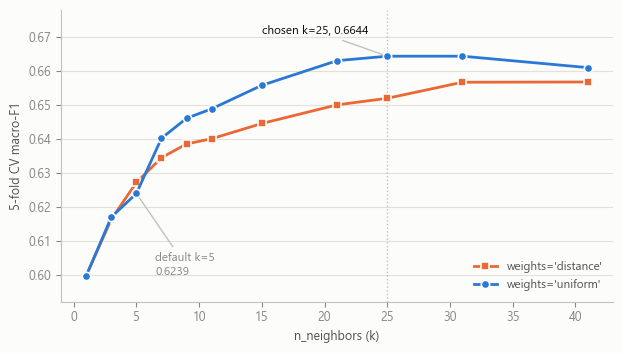

  figures/fig1_knn_sweep.png


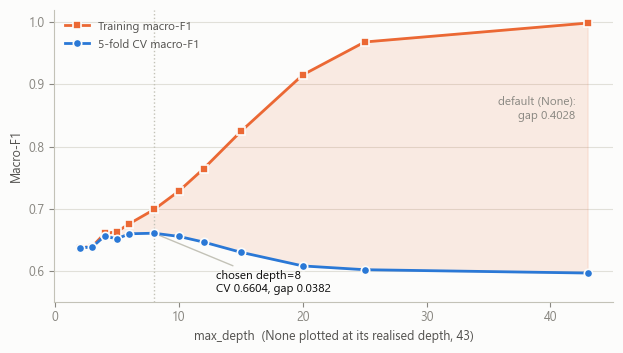

  figures/fig2_tree_depth_sweep.png


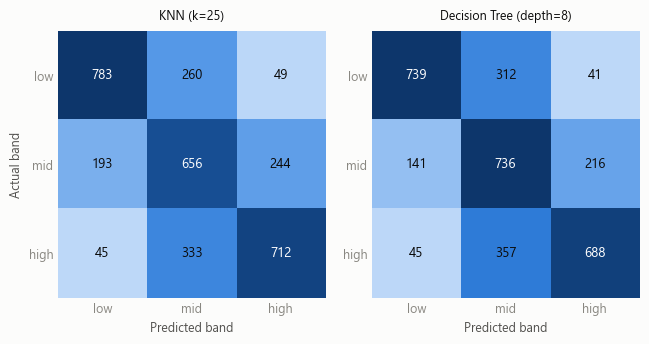

  figures/fig3_confusion_matrices.png


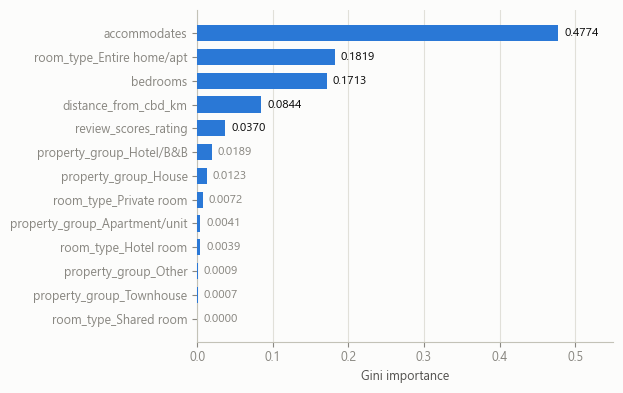

  figures/fig4_feature_importance.png


In [19]:
print("\n" + "="*72)
print("FIGURES")
print("="*72)


BLUE, ORANGE = '#2a78d6', '#eb6834'
SL_INK, SL_INK_2, SL_MUTED = '#0b0b0b', '#52514e', '#898781'
SL_GRID, SL_AXIS, SL_SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE_RAMP = LinearSegmentedColormap.from_list(
    'blues', ['#cde2fb', '#9ec5f4', '#5598e7', '#2a78d6', '#256abf', '#184f95', '#0d366b'])

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'font.size': 9,
    'figure.facecolor': SL_SURFACE,
    'axes.facecolor': SL_SURFACE,
    'axes.edgecolor': SL_AXIS,
    'axes.labelcolor': SL_INK_2,
    'xtick.color': SL_MUTED,
    'ytick.color': SL_MUTED,
    'xtick.labelcolor': SL_MUTED,
    'ytick.labelcolor': SL_MUTED,
    'axes.grid': True,
    'grid.color': SL_GRID,
    'grid.linewidth': 0.8,
    'legend.frameon': False,
})

def tidy(ax, ylabel, xlabel):
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis='x', visible=False)
    ax.set_ylabel(ylabel, color=SL_INK_2)
    ax.set_xlabel(xlabel, color=SL_INK_2)

# --- Figure 1: KNN hyperparameter sweep ---
fig, ax = plt.subplots(figsize=(6.3, 3.6))
uni = [(r[0], r[2]) for r in knn_sweep if r[1] == 'uniform']
dis = [(r[0], r[2]) for r in knn_sweep if r[1] == 'distance']
ax.plot(*zip(*dis), color=ORANGE, lw=2, marker='s', ms=5.5, zorder=3,
        markeredgecolor=SL_SURFACE, markeredgewidth=1.2, label="weights='distance'")
ax.plot(*zip(*uni), color=BLUE, lw=2, marker='o', ms=6, zorder=4,
        markeredgecolor=SL_SURFACE, markeredgewidth=1.2, label="weights='uniform'")

ax.axvline(CHOSEN_K, color=SL_AXIS, lw=1, ls=':', zorder=1)
ax.annotate(f'chosen k={CHOSEN_K}, {dict(uni)[CHOSEN_K]:.4f}',
            xy=(CHOSEN_K, dict(uni)[CHOSEN_K]), xytext=(CHOSEN_K - 1.5, 0.671),
            color=SL_INK, ha='right', fontsize=8.5,
            arrowprops=dict(arrowstyle='-', color=SL_AXIS, lw=1))
ax.annotate(f'default k=5\n{dict(uni)[5]:.4f}',
            xy=(5, dict(uni)[5]), xytext=(6.5, 0.600),
            color=SL_MUTED, fontsize=8.5,
            arrowprops=dict(arrowstyle='-', color=SL_AXIS, lw=1))
tidy(ax, '5-fold CV macro-F1', 'n_neighbors (k)')
ax.set_ylim(0.592, 0.678)
ax.legend(loc='lower right', fontsize=8.5, labelcolor=SL_INK_2)
fig.tight_layout()
fig.savefig('figures/fig1_knn_sweep.png', dpi=200)
plt.show()
print("  figures/fig1_knn_sweep.png")

# --- Figure 2: Decision Tree depth sweep, overfitting gap ---
fig, ax = plt.subplots(figsize=(6.3, 3.6))
UNCONSTRAINED_DEPTH = 43
xs = [UNCONSTRAINED_DEPTH if r[0] is None else r[0] for r in tree_sweep]
cv_ys = [r[1] for r in tree_sweep]
tr_ys = [r[3] for r in tree_sweep]

ax.fill_between(xs, cv_ys, tr_ys, color=ORANGE, alpha=0.12, zorder=1)
ax.plot(xs, tr_ys, color=ORANGE, lw=2, marker='s', ms=5.5, zorder=3,
        markeredgecolor=SL_SURFACE, markeredgewidth=1.2, label='Training macro-F1')
ax.plot(xs, cv_ys, color=BLUE, lw=2, marker='o', ms=6, zorder=4,
        markeredgecolor=SL_SURFACE, markeredgewidth=1.2, label='5-fold CV macro-F1')

ax.axvline(CHOSEN_DEPTH, color=SL_AXIS, lw=1, ls=':', zorder=1)
ax.annotate(f'chosen depth={CHOSEN_DEPTH}\nCV {best_d[1]:.4f}, gap {best_d[4]:.4f}',
            xy=(CHOSEN_DEPTH, best_d[1]), xytext=(13, 0.565),
            color=SL_INK, fontsize=8.5,
            arrowprops=dict(arrowstyle='-', color=SL_AXIS, lw=1))
ax.annotate(f'default (None):\ngap {default_tree[4]:.4f}',
            xy=(UNCONSTRAINED_DEPTH, 0.80), xytext=(UNCONSTRAINED_DEPTH - 1, 0.845),
            color=SL_MUTED, fontsize=8.5, ha='right')
tidy(ax, 'Macro-F1', 'max_depth  (None plotted at its realised depth, 43)')
ax.set_ylim(0.55, 1.02)
ax.legend(loc='upper left', fontsize=8.5, labelcolor=SL_INK_2)
fig.tight_layout()
fig.savefig('figures/fig2_tree_depth_sweep.png', dpi=200)
plt.show()
print("  figures/fig2_tree_depth_sweep.png")

# --- Figure 3: confusion matrices ---
cm_models = [(f'KNN (k={CHOSEN_K})', knn_final.predict(X_test)),
             (f'Decision Tree (depth={CHOSEN_DEPTH})', tree_final.predict(X_test))]
fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.3))
for ax, (name, preds) in zip(axes, cm_models):
    cm = confusion_matrix(y_test, preds, labels=BAND_LABELS)
    ax.imshow(cm, cmap=BLUE_RAMP, vmin=0, vmax=cm.max())
    ax.set_xticks(range(3), BAND_LABELS)
    ax.set_yticks(range(3), BAND_LABELS)
    ax.set_xlabel('Predicted band', color=SL_INK_2)
    ax.set_title(name, color=SL_INK, fontsize=9, pad=8)
    ax.grid(False)
    ax.spines[:].set_visible(False)
    ax.tick_params(length=0)
    for i in range(3):
        for j in range(3):
            frac = cm[i, j] / cm.max()
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=9.5,
                    color='#ffffff' if frac > 0.55 else SL_INK)
axes[0].set_ylabel('Actual band', color=SL_INK_2)
fig.tight_layout()
fig.savefig('figures/fig3_confusion_matrices.png', dpi=200)
plt.show()
print("  figures/fig3_confusion_matrices.png")

# --- Figure 4: tree feature importances ---
fig, ax = plt.subplots(figsize=(6.3, 4.0))
ordered = importances.sort_values()
ax.barh(range(len(ordered)), ordered.values, color=BLUE, height=0.68, zorder=3)
ax.set_yticks(range(len(ordered)), ordered.index)
for i, v in enumerate(ordered.values):
    ax.text(v + 0.008, i, f'{v:.4f}', va='center', fontsize=8.5,
            color=SL_INK if v > 0.03 else SL_MUTED)
tidy(ax, '', 'Gini importance')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.set_xlim(0, 0.55)
fig.tight_layout()
fig.savefig('figures/fig4_feature_importance.png', dpi=200)
plt.show()
print("  figures/fig4_feature_importance.png")

## 5. Feature selection (section 2.4 - Ben)

One filter method (mutual information against continuous price) and one embedded method (the
tuned Decision Tree from section 4), plus a hard case where the two would disagree.

The filter half runs on listings under $1,000, which keeps mutual information from being pulled
around by the 271 extreme listings. The embedded half reuses the tuned tree from section 4 so
the importances describe the same model the report presents.

In [20]:
df_copy = df_rating.dropna(subset=['price']).copy()   # rated + priced listings

# Following the same filling empty bedrooms with median done by Ten so that dat stays consistent 
df_copy['bedrooms']  = df_copy.groupby('room_type')['bedrooms'].transform(lambda x: x.fillna(x.median()))
df_copy['bedrooms']  = df_copy['bedrooms'].fillna(df_copy['bedrooms'].median())   

df_copy = df_copy[df_copy['price'] < 1000]  # remove extreme outliers so that feature selection is more accurate
# One-hot encode categorical variables for mutual information
# Algorithm requires numeric values, so pd.get_dummies convert categorical vars to binary columns

X = df_copy[['review_scores_rating', 'accommodates', 'bedrooms', 'distance_from_cbd_km', 'room_type', 'property_group']]
X = pd.get_dummies(X, columns=['room_type', 'property_group'], drop_first=False)

X = X.fillna(X.median())
y = df_copy['price']

# use built-in mutual_info_regression function to compute mutual information scores
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Top 3 Filter Features (Mutual Information)\n")
print(mi_series.head(3))

# Decision Tree Regressor
# Same decision tree technique as Ten

# Embedded importances come from the tuned depth-8 tree fitted in 2.3, not from a
# fresh unpruned tree. An unpruned tree keeps splitting to isolate individual rows and
# does so on whatever has the most distinct values, which inflates distance_from_cbd_km
# (15,092 distinct values) and review_scores_rating. It also scored worse in CV
# (macro-F1 0.5962 vs 0.6604), and its price bands differ from the ones 2.3 reports.
embedded_importances = (pd.Series(tree_final.feature_importances_, index=X_train.columns)
                        .sort_values(ascending=False))

top_3_embedded = embedded_importances.head(3)
print("Top 3 Embedded Features (Decision Tree)\n")
print(top_3_embedded)

# finding a hard case
hard_case = df_copy[(df_copy['distance_from_cbd_km'] < 1.0) & 
                    (df_copy['review_scores_rating'] > 4.8) & 
                    (df_copy['room_type'] == 'Shared room')][['id', 'price', 'accommodates', 'distance_from_cbd_km', 'review_scores_rating', 'room_type']]
print(hard_case.head(1))

# Reported three ways across the report, so state method and sample every time.
# 2.2 uses Spearman on all rated+priced rows with both present (n = 14,058) -> 0.8643.
pearson_trimmed = df_copy['accommodates'].corr(df_copy['bedrooms'])
spearman_trimmed = df_copy['accommodates'].corr(df_copy['bedrooms'], method='spearman')
print(f"accommodates~bedrooms on the <$1000 subset (n = {len(df_copy)}): "
      f"Pearson {pearson_trimmed:.4f} | Spearman {spearman_trimmed:.4f}")

Top 3 Filter Features (Mutual Information)

accommodates                 0.403054
bedrooms                     0.313188
room_type_Entire home/apt    0.292400
dtype: float64
Top 3 Embedded Features (Decision Tree)

accommodates                 0.477427
room_type_Entire home/apt    0.181902
bedrooms                     0.171318
dtype: float64
                        id  price  accommodates  distance_from_cbd_km  review_scores_rating    room_type
14292  1099552474555242886   75.0             1              0.891973                  4.93  Shared room
accommodates~bedrooms on the <$1000 subset (n = 16102): Pearson 0.8447 | Spearman 0.8464


## 6. PCA and clustering (section 2.5 - Ben)

K-Means and Ward hierarchical clustering on the same feature set, with k chosen by VAT and the
elbow method, then PCA on that feature set for the component loadings and the 2D projection.

In [21]:
# same importing steps as in EODP_A2_FeatureSelection.py to ensure consistency in data preprocessing
cluster_data = df_rating.dropna(subset=['price']).copy()
cluster_data['bedrooms'] = cluster_data.groupby('room_type')['bedrooms'].transform(lambda x: x.fillna(x.median()))
cluster_data['bedrooms'] = cluster_data['bedrooms'].fillna(cluster_data['bedrooms'].median())

# This removes extreme outliers so that clustering is more accurate. As stated by Ten only 271 listings are above $1000
# Don't do this and you get weird groups
cluster_data = cluster_data[cluster_data['price'] < 1000]  

cluster_data = pd.get_dummies(cluster_data, columns=['room_type', 'property_group'], drop_first=False)

# chosen set 
features = ['price', 'accommodates', 'distance_from_cbd_km', 'room_type_Entire home/apt']

x_cluster = cluster_data[features].copy()
scaler = StandardScaler() # this is better
scaled_data = scaler.fit_transform(x_cluster)

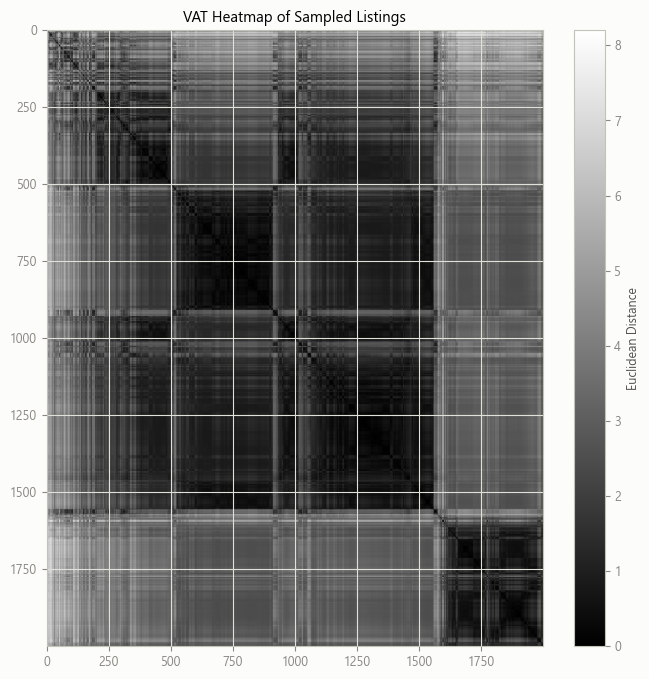

In [22]:
# VAT to determine number of clusters #

# randomly sample 2000 listings so that VAT generation doesn't crash or take forever.
np.random.seed(3000)
sample_indices = np.random.choice(scaled_data.shape[0], size=2000, replace=False)
X_sample = scaled_data[sample_indices]

# calculate pairwise Euclidean distances for the sampled data
distance_matrix = pdist(X_sample, metric='euclidean')

# Visualize the VAT 
Z = linkage(distance_matrix, method='single')
ordered_indices = leaves_list(Z)

sq_dist_matrix = squareform(distance_matrix)
ordered_sq_matrix = sq_dist_matrix[ordered_indices, :][:, ordered_indices]


plt.figure(figsize=(8, 8))
plt.imshow(ordered_sq_matrix, cmap='gray', aspect='auto')
plt.colorbar(label='Euclidean Distance')
plt.title("VAT Heatmap of Sampled Listings")
plt.show()
# Suggests K = 3-4 clusters

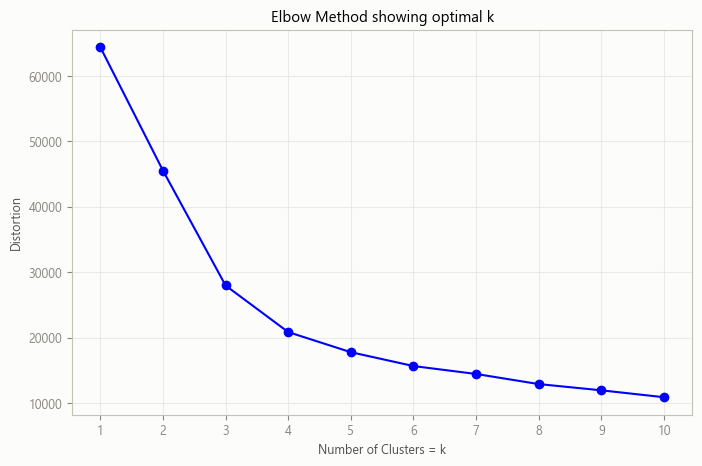

In [23]:
# Elbow method to confirm k value #

# set range of k values to test
k_values = range(1, 11)
distortions = []

for k in k_values:
    # random_state is set for reproducibility
    kmeans = KMeans(n_clusters=k, random_state=3000)
    kmeans.fit(scaled_data)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, distortions, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters = k')
plt.ylabel('Distortion')
plt.title('Elbow Method showing optimal k')
plt.xticks(k_values)
plt.grid(True, alpha=0.6)
plt.show()

# Showed k = 3 is a better choice than k = 4

PCA Loadings:
                                 PC1       PC2
price                      0.610880  0.030638
accommodates               0.592923  0.137314
distance_from_cbd_km       0.076133  0.933507
room_type_Entire home/apt  0.519106 -0.329805

Variance explained by PC1: 50.8%
Variance explained by PC2: 26.4%


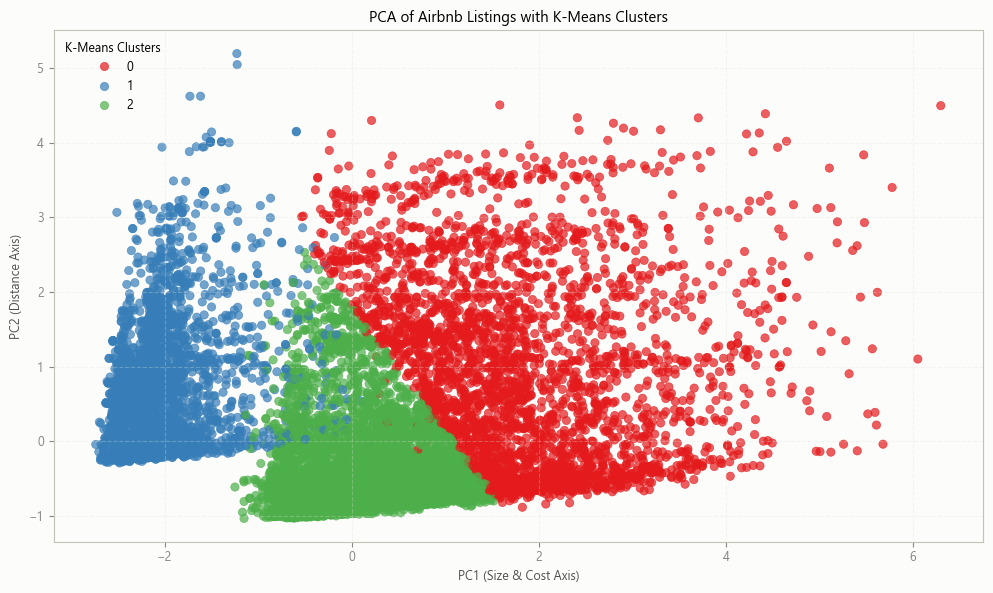

In [24]:
# Final clustering and PCA visualization #

kmeans = KMeans(n_clusters=3, random_state=3000)
cluster_data['kmeans_cluster'] = kmeans.fit_predict(scaled_data)

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
cluster_data['pca1'] = pca_components[:, 0]
cluster_data['pca2'] = pca_components[:, 1]

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print("PCA Loadings:\n", loadings)
print(f"\nVariance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x = 'pca1',
    y = 'pca2',
    hue = 'kmeans_cluster', 
    data = cluster_data, 
    palette='Set1', 
    alpha=0.7, 
    edgecolor=None
)

plt.title('PCA of Airbnb Listings with K-Means Clusters')
plt.xlabel(f'PC1 (Size & Cost Axis)')
plt.ylabel(f'PC2 (Distance Axis)')
plt.legend(title='K-Means Clusters', loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

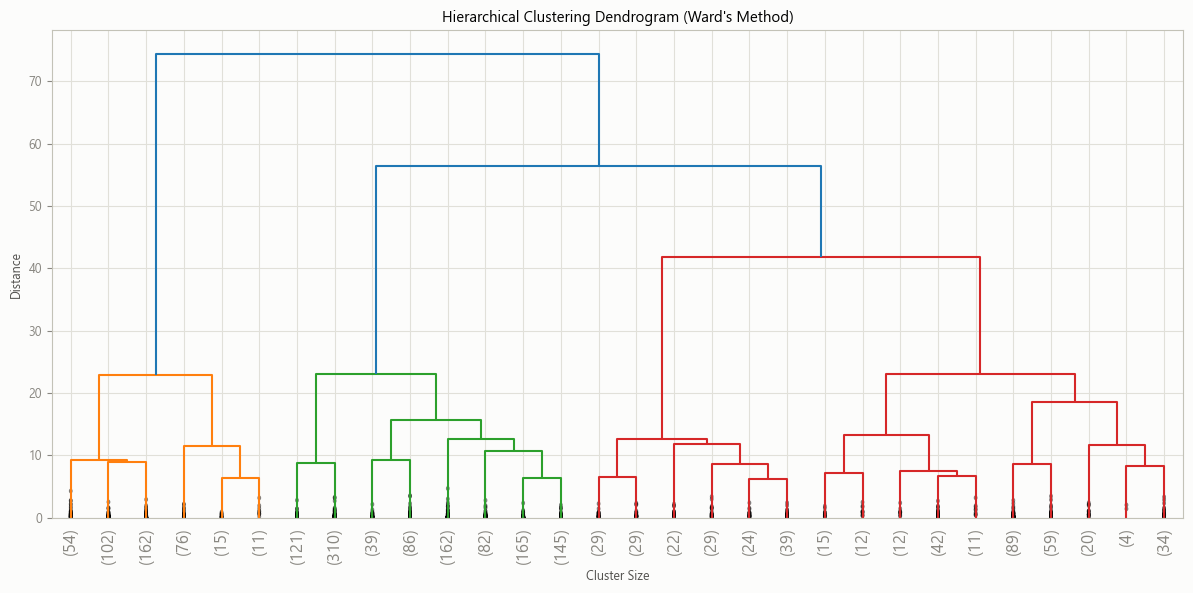

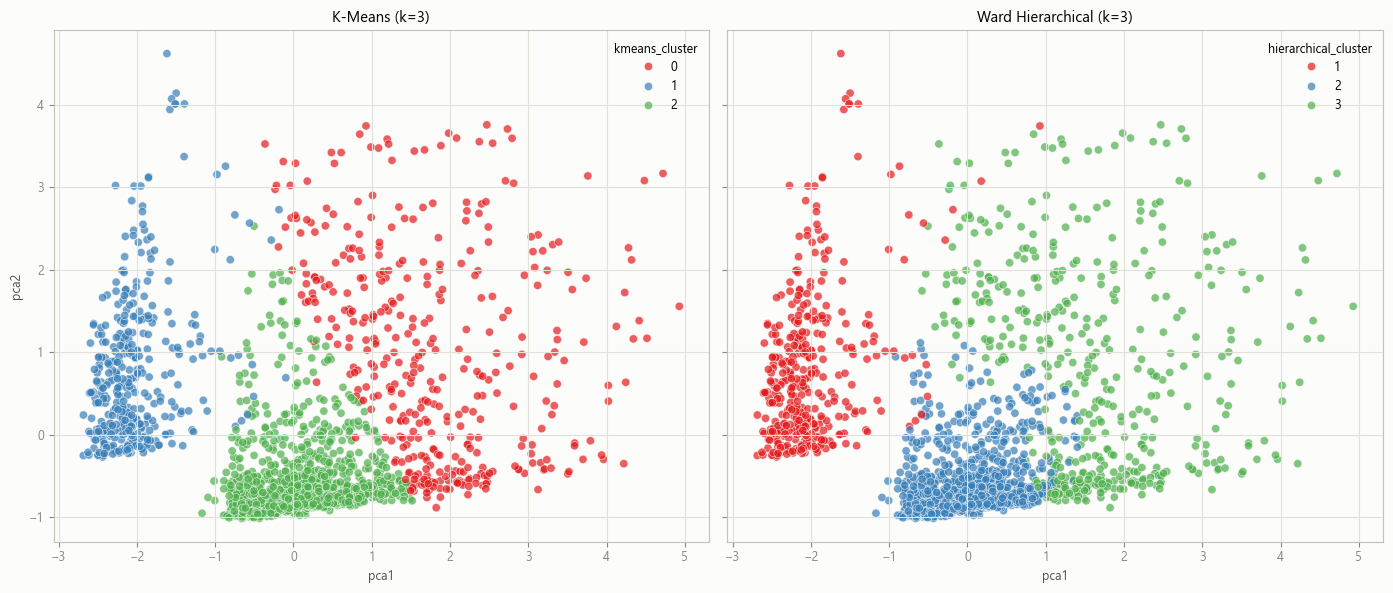

ARI: 0.8219133957002546
hierarchical_cluster    1     2    3
kmeans_cluster                      
0                       2    22  374
1                     418     0    1
2                       0  1088   95

Average Property Profile per Cluster
                     price  accommodates  distance_from_cbd_km  room_type_Entire home/apt
kmeans_cluster                                                                           
0               466.767813      6.992429             24.121358                   0.988795
1               123.794200      1.941945             13.455141                   0.000000
2               256.693116      3.585997              5.380635                   1.000000

Average Property Profile per Hierarchical Cluster
                           price  accommodates  distance_from_cbd_km  room_type_Entire home/apt
hierarchical_cluster                                                                           
1                     127.102830      1.966571             1

In [25]:
# Hierarchical clustering and comparison with K-Means #
# This section was done with the help of Generative AI (Gemini) #
np.random.seed(3000)
index = np.random.choice(len(scaled_data), size=2000, replace=False)
Z_ward = linkage(scaled_data[index], method='ward')

# Create a dendrogram to visualize the hierarchical clustering
plt.figure(figsize=(12, 6))
dendrogram(Z_ward, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward\'s Method)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


cluster_data['hierarchical_cluster'] = fcluster(linkage(scaled_data, method='ward'), t=3, criterion='maxclust')
sample = cluster_data.iloc[index].copy()
sample['hierarchical_cluster'] = fcluster(Z_ward, t=3, criterion='maxclust')

# Compare K-Means and Hierarchical clustering results visually
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
sns.scatterplot(x='pca1', y='pca2', hue='kmeans_cluster', data=sample,
                palette='Set1', alpha=0.7, ax=axes[0])
axes[0].set_title('K-Means (k=3)')
sns.scatterplot(x='pca1', y='pca2', hue='hierarchical_cluster', data=sample,
                palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('Ward Hierarchical (k=3)')
plt.tight_layout()
plt.show()

# 3. Agreement between the two methods
print("ARI:", adjusted_rand_score(sample['kmeans_cluster'], sample['hierarchical_cluster']))
print(pd.crosstab(sample['kmeans_cluster'], sample['hierarchical_cluster']))

# Mean profiles of clusters
cluster_profiles = cluster_data.groupby('kmeans_cluster')[features].mean()
hierarchical_profiles = cluster_data.groupby('hierarchical_cluster')[features].mean()

print("\nAverage Property Profile per Cluster")
print(cluster_profiles)
print("\nAverage Property Profile per Hierarchical Cluster")
print(hierarchical_profiles)